                 UQNO  PERSONNO      Province Q12NIGHTS Q13GENDER  Q14AGE  \
0  101000170000003001         1  Western Cape       Yes      Male      52   
1  101000170000003001         2  Western Cape       Yes    Female      50   
2  101000170000005101         1  Western Cape       Yes      Male      39   
3  101000170000007201         1  Western Cape       Yes      Male      40   
4  101000170000009301         1  Western Cape       Yes      Male      73   

  Q15POPULATION                       Q16MARITALSTATUS  \
0         White                                Married   
1         White                                Married   
2      Coloured  Living together like husband and wife   
3         White                   Divorce or separated   
4      Coloured  Living together like husband and wife   

                         Q17EDUCATION Q20SELFRESPOND  ... age_grp1  \
0          Grade 10/Standard 8/Form 3             No  ...    50-54   
1  Grade 12/Standard 10/Form 5/Matric           

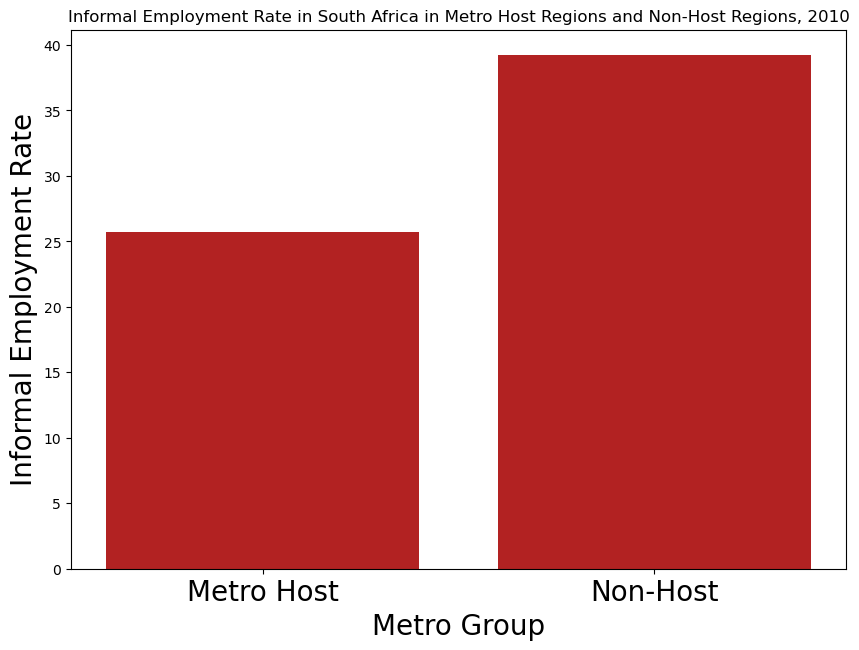

In [14]:
## load data on South Africa labor stats
import pandas as pd
import matplotlib.pyplot as plt
df = labor_data = pd.read_stata("/Users/maevepadien/Downloads/southafrica_qss.dta")
print(df.head())

print(df["Metro_code"].unique())
print(df["Status_Exp"].unique())
# create list of hosting metros
host_metros = ["Cape Town", "Nelson Mandela Metro", "eThekwini", "Tshwane", "Johannesburg"]
# use lamda function to create variable on hosting group (yes or no) in dataframe
df["host_group"] = df["Metro_code"].apply(lambda x: "Metro Host" if x in host_metros else "Non-Host")
# update df to get when employed
employed = df[df["Status_Exp"] == "Employed"]
# get to informal employment sorted by if hosting or not, then convert to rate (takes advantage of boolean 0-1 property)
informal_count = employed.groupby("host_group")["Infempl"].apply(lambda x: (x == 'Informal employment').mean() * 100)

# taken from classwork as guide
plt.figure(figsize=(10,7))
plt.bar(informal_count.index, informal_count, label = "Informal Employment Rate", color="firebrick")
plt.xticks(informal_count.index, informal_count.index, fontsize=20)
plt.xlabel("Metro Group", fontsize=20)
plt.ylabel("Informal Employment Rate", fontsize=20)
plt.title("Informal Employment Rate in South Africa in Metro Host Regions and Non-Host Regions, 2010")
plt.savefig("milestone1_1.png", bbox_inches="tight")

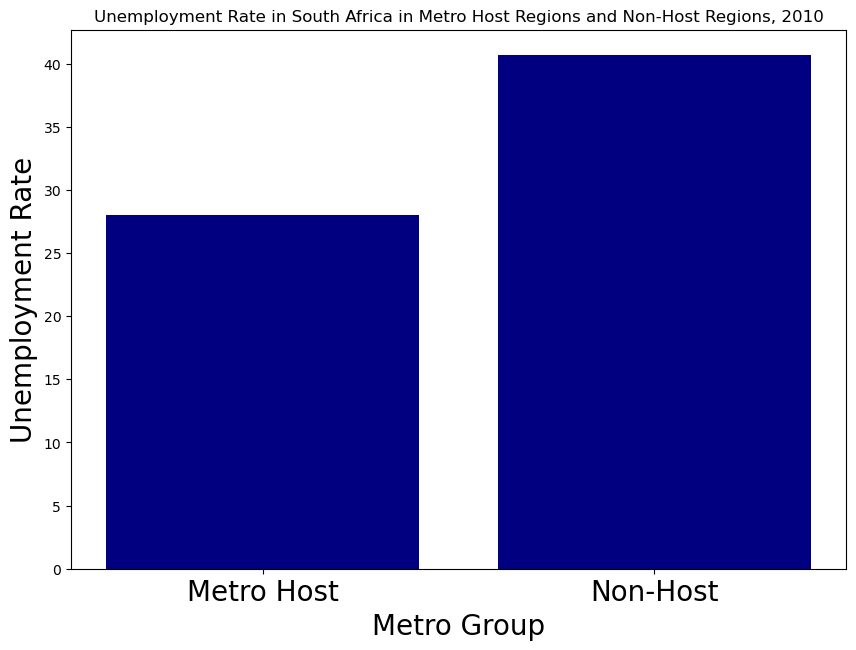

In [15]:
# look at unemployment
unemployment_count = df[df["Status_Exp"].isin(["Employed", "Unemployed"])
    ].groupby("host_group")["Status_Exp"].apply(lambda x: (x == "Unemployed").mean() * 100)
# taken from classwork as guide
plt.figure(figsize=(10,7))
plt.bar(unemployment_count.index, unemployment_count, label = "Unemployment Rate", color="navy")
plt.xticks(unemployment_count.index, unemployment_count.index, fontsize=20)
plt.xlabel("Metro Group", fontsize=20)
plt.ylabel("Unemployment Rate", fontsize=20)
plt.title("Unemployment Rate in South Africa in Metro Host Regions and Non-Host Regions, 2010")
plt.savefig("milestone1_2.png", bbox_inches="tight")